### Notebook overview
This notebook demonstrates **unconditional forecasting** with **covariates** using the **Moirai** model (also referred to as BISTRO in the context of this project).

- **Task**: Forecast US CPI inflation (year-over-year), incorporating the **Policy Rate** as a past dynamic covariate.
- **Model**: Moirai, a Universal Time Series Forecasting Transformer that handles arbitrary number of variates using Any-variate Attention.
- **Scenario**: We simulate a scenario where recent covariate data might be missing/unknown (unconditional on future covariate paths).
- **Workflow**: Load target (CPI) and covariate (Policy Rate), merge them, prepare the dataset with `past_feat_dynamic_real`, and generate probabilistic forecasts.

### Data
- Source: BIS CPI statistics (US CPI, YoY; monthly) and Central Bank Policy Rate.
- More series: see `data/`.


### Step 1 - Setup
- Make the project code in `src/` available to the notebook.
- Import the required libraries and helper functions.


### Google Colab users
- Colab may preinstall **NumPy 2.x**.
- After the downgrade runs, it triggers an automatic restart by terminating the current process.


In [1]:
import os
import subprocess

try:
    import numpy as np
    if np.__version__.startswith('2.'):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        # 2. Install the 1.x stack and compatible dependencies to stop the red errors
        # We include specific versions of pandas/scipy that like NumPy 1.x
        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ])

        print("✅ Install complete. Restarting runtime automatically...")

        # 3. Kill the process to force a reload of the new (older) library
        os.kill(os.getpid(), 9)
    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")
except ImportWarning:
    pass

✅ Success! Using NumPy version: 1.26.4


In [1]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    print("Running in Google Colab. Setting up repository quietly...")

    # Added -q to suppress git clone output
    !git clone -q https://github.com/bis-med-it/bistro.git

    if not 'uni2ts' in sys.modules:
        print("Installing dependencies (this may take a moment)...")
        # Added -q for pip, and redirected all stdout/stderr to completely hide warnings
        !pip install -q -r /content/bistro/requirements.txt > /dev/null 2>&1
        print("Installation complete!")

Running in Google Colab. Setting up repository quietly...
Installing dependencies (this may take a moment)...
Installation complete!


### Restart Colab to finish setup

To make sure the newly installed packages load correctly, please restart the runtime:

**Runtime → Restart session**

After it restarts, continue by running the next cells below.

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
  os.chdir('/content/bistro/script')

repo_root = Path(os.path.join('..')).resolve()
src_root = Path(os.path.join('..', 'src')).resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


In [2]:
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison, ar1_forecast

from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_long_df_monthly_for_daily_inference,
)

### Step 2 - Data and settings
- Set the forecast horizon (PDT) and how much history the model reads (CTX).
- Configure the Moirai model settings.


In [3]:
MODEL_REPO = repo_root / 'bistro-finetuned'

FREQ = 'M'  # monthly data frequency

PDT = 12   # how many months to forecast ahead
CTX = 240 # how many months of past data the model reads
PSZ = 32  # steps per month (daily patch grid)
BSZ = 32  # batch size for faster forecasting
ROLLING_WINDOWS = 1  # how many starting points to evaluate
WINDOW_DISTANCE = 20  # gap (in months) between those starting points

FORECAST_START_DATE = '2022-03-01'  # first forecast month

config = {
    "MODEL_REPO": str(MODEL_REPO),
    "PDT": PDT,
    "CTX": CTX,
    "PSZ": PSZ,
    "BSZ": BSZ,
    "ROLLING_WINDOWS": ROLLING_WINDOWS,
    "WINDOW_DISTANCE": WINDOW_DISTANCE,
    "FORECAST_START_DATE": FORECAST_START_DATE,
}


- Load the CPI series (target) and Policy Rate series (covariate).


In [4]:
series1 = repo_root / 'data' / 'bis_cpi_us_yoy_m.csv'
series2 = repo_root / 'data' / 'bis_cbpol_us_m.csv'

df_inf = pd.read_csv(series1, index_col=0)
df_inf.index = pd.to_datetime(df_inf.index).to_period(freq=FREQ)

df_pol = pd.read_csv(series2, index_col=0)
df_pol.index = pd.to_datetime(df_pol.index).to_period(freq=FREQ)

- **Covariate Handling**: Merge the policy rate into the dataframe.
- **Unconditional Scenario**: The policy rate is provided as `past_feat_dynamic_real` (past-only conditioning information) and is not forecasted. In the chart, it is shown only up to `TRAIN_END`.


In [5]:
df = df_inf.copy()
df["item_id"] = "cpi_us_yoy_m"
df = df.merge(df_pol, right_index=True, left_index=True, how="inner")
df.columns = ["target", "item_id", "past_dynamic_real"]

target_col = "target"

prep = prepare_long_df_monthly_for_daily_inference(
    df,
    item_id_col="item_id",
    target_col=target_col,
    past_dynamic_real_cols=["past_dynamic_real"],
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

if prep.windows < 1:
    raise ValueError(
        f'Not enough test data after cutoff {prep.train_end} to create a window: '
        f'test_len={(prep.df_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}.'
    )

prep.daily_long_df.head()

,target,past_dynamic_real,item_id
ts,,,
1954-07-31,0.373134,0.25,cpi_us_yoy_m
1954-08-01,0.373134,0.25,cpi_us_yoy_m
1954-08-02,0.373134,0.25,cpi_us_yoy_m
1954-08-03,0.373134,0.25,cpi_us_yoy_m
1954-08-04,0.373134,0.25,cpi_us_yoy_m


In [6]:
ds = PandasDataset.from_long_dataframe(
    prep.daily_long_df,
    item_id="item_id",
    past_feat_dynamic_real=["past_dynamic_real"],
    feat_dynamic_real=[],
)

train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=prep.windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)

In [7]:
print(
    f"windows={prep.windows}, pdt_steps={prep.pdt_steps}, ctx_steps={prep.ctx_steps}, dist_steps={prep.dist_steps}"
)

windows=1, pdt_steps=384, ctx_steps=7680, dist_steps=640


### Step 3 - Run BISTRO (Moirai)
- Load the pretrained BISTRO checkpoint.
- **Any-variate Attention**: Specify `feat_dynamic_real_dim` and `past_feat_dynamic_real_dim` so Moirai correctly attends to the covariate channels.
- Generate probabilistic forecasts.


In [8]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=int(config.get("NUM_SAMPLES", 100)),
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

Loading weights from local directory


FileNotFoundError: No such file or directory: /content/bistro/bistro-finetuned/model.safetensors

In [ ]:
predictor = model.create_predictor(batch_size=BSZ)

inputs    = list(test_data.input)
labels    = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

### Step 4 - Review results
- Summarise forecasts in a table (median by window).
- Plot forecast paths and uncertainty bands against the realised series.


In [ ]:
bistro_monthly_by_window = {}
rmse_rows = []

for w in range(prep.windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)
    label_target = np.asarray(labels[w]["target"], dtype=float)

    inp_target = (
        np.asarray(inputs[w]["target"], dtype=float)
        if "target" in inputs[w]
        else np.asarray([], dtype=float)
    )
    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1],
        },
        index=pred_index,
    )

    actual = prep.df_monthly_target[target_col].reindex(pred_index).astype(float)
    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()
    rmse_bistro = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    # AR(1) baseline (trained on CTX months ending at train_end_w)
    train_end_w = pred_index[0] - 1
    train_y = prep.df_monthly_target[target_col].loc[:train_end_w].tail(CTX).astype(float)
    try:
        ar1_pred = ar1_forecast(
            train_y,
            pred_index,
            method="statsmodels",
            trend="c",
            validate_index=True,
        )
    except Exception as e:
        ar1_pred = pd.Series(np.nan, index=pred_index, dtype=float)
        print(f"AR(1) failed for window {w}: {e}")

    dfw["ar1_pred"] = ar1_pred

    valid_ar1 = actual.notna() & ar1_pred.notna()
    rmse_ar1 = float(np.sqrt(np.mean((ar1_pred[valid_ar1] - actual[valid_ar1]) ** 2))) if valid_ar1.any() else np.nan
    r_rmse = float(rmse_bistro / rmse_ar1) if (np.isfinite(rmse_bistro) and np.isfinite(rmse_ar1) and rmse_ar1 != 0) else np.nan

    bistro_monthly_by_window[w] = dfw

    rmse_rows.append(
        {
            "window": w,
            "test_start": pred_index[0],
            "test_end": pred_index[-1],
            "rmse_bistro": rmse_bistro,
            "rmse_ar1": rmse_ar1,
            "r_rmse": r_rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)

rmse_table

,window,test_start,test_end,rmse_bistro,rmse_ar1,r_rmse,n_valid
0,0,2022-03,2023-02,0.55248,0.858439,0.643587,12


In [ ]:
rmse_table

,window,test_start,test_end,rmse_bistro,rmse_ar1,r_rmse,n_valid
0,0,2022-03,2023-02,0.55248,0.858439,0.643587,12


In [ ]:
bistro_monthly_by_window[0]

,bistro_pred,bistro_lo,bistro_hi,ar1_pred
2022-03,8.654991,8.281992,8.903803,7.778919
2022-04,8.582325,8.212604,8.888740,7.688703
2022-05,8.226748,7.785376,8.584940,7.600375
2022-06,8.008833,7.616836,8.367638,7.513895
2022-07,7.940762,7.634845,8.261411,7.429226
2022-08,7.800723,7.375328,8.100710,7.346328
2022-09,7.436814,7.155053,7.838816,7.265165
2022-10,6.965327,6.604118,7.442576,7.185701
2022-11,6.674760,6.190138,7.212453,7.107900
2022-12,6.321872,5.882840,6.843817,7.031727


In [ ]:
w = 0

forecast_start_w = prep.forecast_start + w * WINDOW_DISTANCE
train_end_w = forecast_start_w - 1

df_actual = prep.df_monthly_target[[target_col]].rename(columns={target_col: "actual"})
df_pred = bistro_monthly_by_window[w]

plot_from = forecast_start_w - min(CTX, 120)
plot_to = df_pred.index.max()

df_plot = df_actual.join(df_pred[["bistro_pred", "ar1_pred"]], how="outer").sort_index()
df_plot = df_plot.loc[plot_from:plot_to]

# Add covariate (policy rate) for display on a secondary axis.
df_cov = prep.df_dt[["past_dynamic_real"]].copy()
df_cov.index = df_cov.index.to_period(FREQ)
df_cov = df_cov.rename(columns={"past_dynamic_real": "policy_rate"})
df_cov = df_cov.loc[:train_end_w]
df_plot = df_plot.join(df_cov, how="left")

fig, ax = plot_publication_forecast_comparison(
    df_plot,
    actual_col="actual",
    forecast_cols={
        "bistro_pred": "BISTRO (median)",
        "ar1_pred": "AR(1)",
    },
    forecast_start=forecast_start_w,
    title=f"{target_col} — unconditional scenario (window {w})",
    ylabel="YoY inflation (%)",
    y_fmt="percent",
    percent_scale=100.0,
    savepaths=None,
)

from matplotlib.ticker import PercentFormatter

policy_color = "C3"
ax2 = ax.twinx()
x = df_plot.index.to_timestamp()
ax2.plot(x, df_plot["policy_rate"].to_numpy(dtype=float), color=policy_color, lw=1.6, label="Policy rate")
ax2.set_ylabel("Policy rate (%)")
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100.0))
ax2.spines["right"].set_color(policy_color)
ax2.tick_params(axis="y", colors=policy_color)
ax2.yaxis.label.set_color(policy_color)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", frameon=False, ncol=2)

out_dir = repo_root / "script" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "forecast_unconditional_scenario.png", bbox_inches="tight")

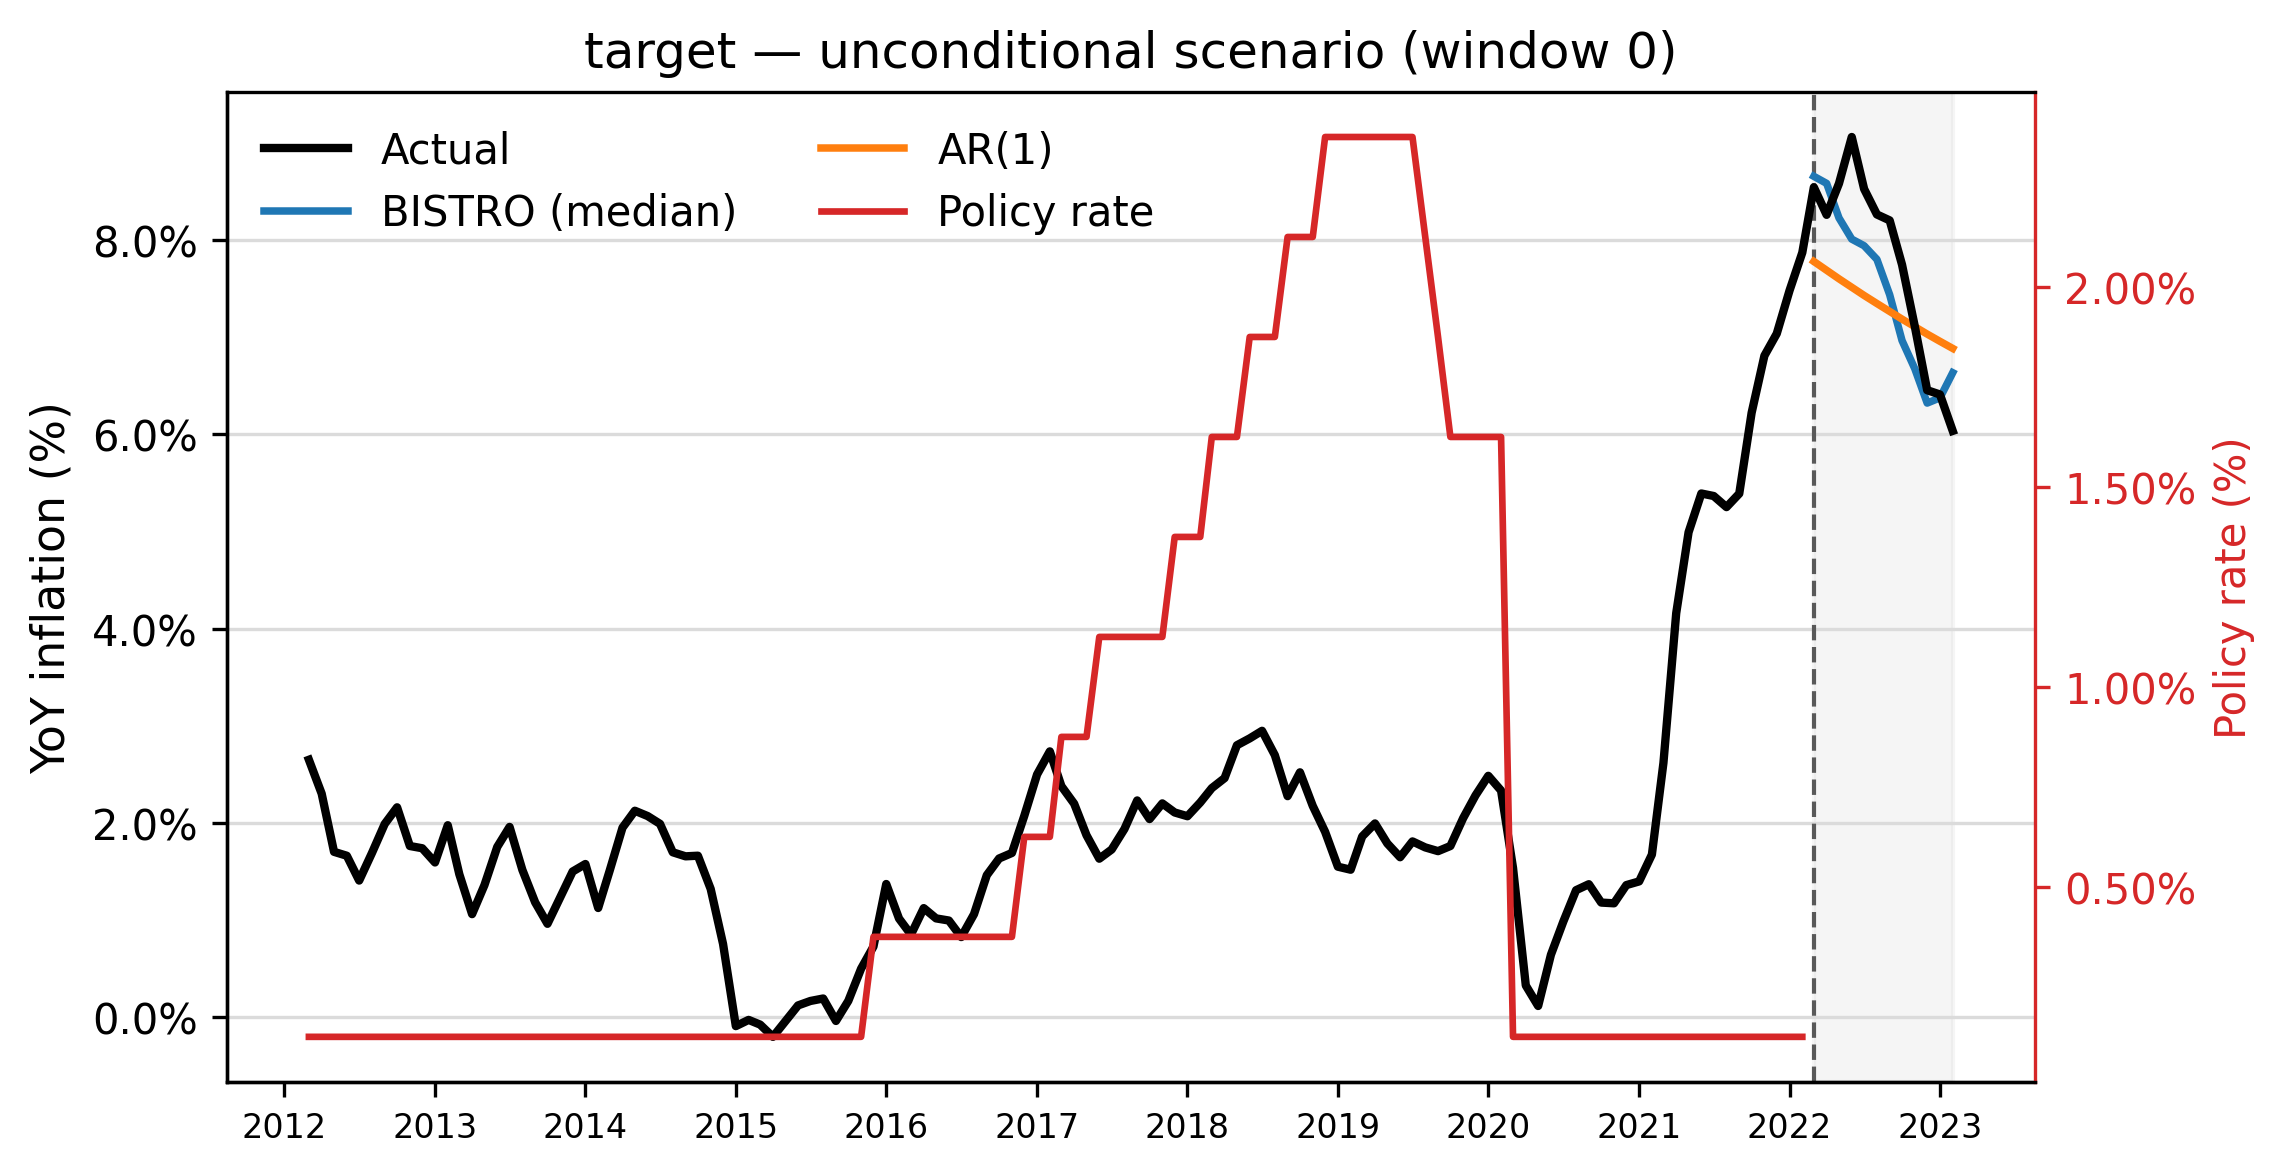

In [ ]:
fig